<hr style='border-top:4px solid #1F77B4;'>

<h2><span style="color: #1F77B4; font-size: 35px">Chapitre 7</span></h2>
<h1><span style="color: #1F77B4; font-size: 50px">La méthode des $k$ plus proches voisins</span></h1>

Ce carnet reprend, dans l'ordre du chapitre, l'ensemble des extraits de code présentés dans le texte : implémentation NumPy de la méthode et validation avec `scikit-learn`, sensibilité de la distance à l'échelle des variables à partir de huit passagers du <i>Titanic</i>, standardisation et pipeline sur le jeu de données <i>Wine</i>, sélection du nombre de voisins par validation croisée, fléau de la dimension et régression sur le jeu de données <i>diabetes</i>. Les cellules doivent être exécutées séquentiellement, car certaines réutilisent des variables ou des résultats définis en amont.

**Bibliothèques requises** : `numpy`, `pandas`, `matplotlib` et `scikit-learn` (≥ 1.9).  
**Données externes** : aucun fichier externe n'est nécessaire.  
**Exécution** : les versions utilisées sont affichées par la cellule de configuration.

<hr style='border-top:4px solid #1F77B4;'>

In [1]:
# Configuration générale : bibliothèques, versions et affichage
import sys
from importlib.metadata import version as package_version

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PAQUETS = ('numpy', 'pandas', 'matplotlib', 'scikit-learn')

print(f"{'python':<18} {sys.version.split()[0]}")
for paquet in PAQUETS:
    print(f"{paquet:<18} {package_version(paquet)}")

plt.rcParams.update({
    'font.size': 13,
    'mathtext.fontset': 'cm',
    'text.usetex': False,
})

# Couleurs du livre (palette viridis)
VIOLET, SARCELLE, VERT = '#482878', '#21918c', '#5ec962'
BLEU    = '#3b528b'    # nuages de données / éléments neutres
MAGENTA = '#bf00bf'    # courbes de modèle
BORD = {VIOLET: '#2e1a4d', SARCELLE: '#14615d', VERT: '#3a7d3f', BLEU: '#2c3e6b'}
ZONE = {VIOLET: '#d5cbe4', SARCELLE: '#c4e3e1', VERT: '#def2e0'}

python             3.12.13
numpy              2.5.1
pandas             3.0.3
matplotlib         3.11.0
scikit-learn       1.9.0


In [2]:
# Fonction utilitaire de sauvegarde des figures (PDF)
import os

def save_figure(fig, path):
    directory = os.path.dirname(path)
    if directory:
        os.makedirs(directory, exist_ok=True)
    fig.savefig(f"{path}.pdf", format="pdf", bbox_inches='tight')

<hr style='border-top:4px solid #1F77B4;'>

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 7.1 : Implémentation complète de la méthode avec NumPy, validée sur <em>Iris</em></h3>

In [3]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

def knn_predire(X_train, y_train, X_test, k):
    """Prédiction k-PPV par vote majoritaire (distance euclidienne)."""
    predictions = []
    for x in X_test:
        dist = np.sqrt(((X_train - x) ** 2).sum(axis=1))
        indices = np.argsort(dist)[:k]
        classes, comptes = np.unique(y_train[indices], return_counts=True)
        predictions.append(classes[np.argmax(comptes)])
    return np.array(predictions)

iris = load_iris()
X_tr, X_te, y_tr, y_te = train_test_split(
    iris.data, iris.target, test_size=0.3,
    stratify=iris.target, random_state=42)
y_pred = knn_predire(X_tr, y_tr, X_te, k=5)

# Affichage
exactitude_np = (y_pred == y_te).mean()
print(f"Exactitude (implémentation NumPy) : {exactitude_np:.3f}")

Exactitude (implémentation NumPy) : 0.978


<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 7.2 : Classification par $k$ plus proches voisins avec scikit-learn</h3>

In [4]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_tr, y_tr)

# Affichage
y_pred_sk = knn.predict(X_te)
exactitude_sk = knn.score(X_te, y_te)
identique = bool(np.array_equal(y_pred, y_pred_sk))
print(f"Exactitude (scikit-learn) : {exactitude_sk:.3f}")
print(f"Identique à NumPy : {identique}")

Exactitude (scikit-learn) : 0.978
Identique à NumPy : True


<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 7.3 : Huit passagers du <em>Titanic</em> et prédiction de référence ($k = 5$, tarif en livres)</h3>

In [5]:
import numpy as np
import pandas as pd

# Petit jeu de données construit
donnees = pd.DataFrame({
    'age':    [22, 38, 26, 35, 28, 54, 2, 40],
    'tarif':  [7, 71, 8, 53, 8, 52, 21, 8],
    'survie': ['non', 'oui', 'non', 'oui', 'non', 'oui', 'oui', 'non']
})

# Variables explicatives et variable cible
X = donnees[['age', 'tarif']].to_numpy(dtype=float)
y = donnees['survie'].to_numpy()

# Nouveau passager à classer
x_new = np.array([30.0, 30.0])

dist = np.sqrt(((X - x_new) ** 2).sum(axis=1))
ordre = np.argsort(dist)
k = 5
voisins_idx = ordre[:k]
val, comptes = np.unique(y[voisins_idx], return_counts=True)
prediction = val[np.argmax(comptes)]

# --- Affichage ---
titre = f"k-PPV (k={k}) : nouveau passager (âge=30, tarif=30)"
L = 50
print("=" * L)
print(titre)
print("=" * L)
print(f"{'Passager':<12}{'Distance':<12}{'Survie'}")
print("-" * L)
for i in voisins_idx:
    print(f"{i + 1:<12}{dist[i]:<12.2f}{y[i]}")
print("-" * L)
print(f"Prédiction : {prediction} ({comptes.max()} voix contre {comptes.min()})")
print("=" * L)

k-PPV (k=5) : nouveau passager (âge=30, tarif=30)
Passager    Distance    Survie
--------------------------------------------------
5           22.09       non
3           22.36       non
4           23.54       oui
8           24.17       non
1           24.35       non
--------------------------------------------------
Prédiction : non (4 voix contre 1)


<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 7.4 : Reprise avec le tarif exprimé en shillings (1 livre = 20 shillings)</h3>

In [6]:
# Mêmes données, tarif converti en shillings
X_sh = X.copy()
X_sh[:, 1] *= 20
x_new_sh = x_new.copy()
x_new_sh[1] *= 20

distances = np.sqrt(((X_sh - x_new_sh) ** 2).sum(axis=1))
ordre = np.argsort(distances)

# --- Affichage ---
titre = "k-PPV avec tarif converti en shillings (échelle déformée)"
L = max(50, len(titre))

print("=" * L)
print(titre)
print("=" * L)
print(f"{'Rang':<6}{'Passager':<10}{'Distance':<12}{'Survie'}")
print("-" * L)
for rang, i in enumerate(ordre[:5], start=1):
    print(f"{rang:<6}{i + 1:<10}{distances[i]:<12.2f}{y[i]}")
print("-" * L)
print(f"{'k':<6}{'Prédiction'}")
for k in (1, 3, 5):
    voisins = y[ordre[:k]]
    valeurs, comptes = np.unique(voisins, return_counts=True)
    prediction = valeurs[np.argmax(comptes)]
    print(f"{k:<6}{prediction}")
print("=" * L)

k-PPV avec tarif converti en shillings (échelle déformée)
Rang  Passager  Distance    Survie
---------------------------------------------------------
1     7         182.16      oui
2     5         440.00      non
3     3         440.02      non
4     8         440.11      non
5     6         440.65      oui
---------------------------------------------------------
k     Prédiction
1     oui
3     non
5     non


**Complément** : vérification de l'exercice du livre - après standardisation, les trois plus proches voisins sont les mêmes dans les deux unités.

In [7]:
# Complément : voisinages identiques après standardisation
from sklearn.preprocessing import StandardScaler

resultats = []
for nom, donnees, requete in [('Livres', X, x_new), ('Shillings', X_sh, x_new_sh)]:
    sc = StandardScaler().fit(donnees)
    d_std = np.sqrt(((sc.transform(donnees)
                      - sc.transform([requete])) ** 2).sum(axis=1))
    voisins = (np.argsort(d_std)[:3] + 1).tolist()
    resultats.append((nom, voisins))

# --- Affichage ---
titre = "Effet de la standardisation sur le voisinage (k=3)"
L = max(50, len(titre))

print("=" * L)
print(titre)
print("=" * L)
print(f"{'Échelle':<12}{'3 plus proches voisins'}")
print("-" * L)
for nom, voisins in resultats:
    print(f"{nom:<12}{voisins}")
print("=" * L)

Effet de la standardisation sur le voisinage (k=3)
Échelle     3 plus proches voisins
--------------------------------------------------
Livres      [5, 3, 4]
Shillings   [5, 3, 4]


<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 7.5 : Effet de la standardisation sur <em>Wine</em> (proline et flavonoïdes, $k = 15$)</h3>

In [8]:
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler

wine = load_wine()
X_w = wine.data[:, [12, 6]]  # proline et flavonoïdes
X_w_tr, X_w_te, y_w_tr, y_w_te = train_test_split(
    X_w, wine.target, test_size=0.3,
    stratify=wine.target, random_state=42)

# Sans standardisation
knn_brut = KNeighborsClassifier(n_neighbors=15).fit(X_w_tr, y_w_tr)
exactitude_brut = knn_brut.score(X_w_te, y_w_te)

# Avec standardisation (ajustée sur l'entraînement seulement)
scaler = StandardScaler().fit(X_w_tr)
knn_std = KNeighborsClassifier(n_neighbors=15).fit(scaler.transform(X_w_tr), y_w_tr)
exactitude_std = knn_std.score(scaler.transform(X_w_te), y_w_te)

# --- Affichage ---
titre = "k-PPV (k=15) sur Wine : effet de la standardisation"
L = max(50, len(titre))

print("=" * L)
print(titre)
print("=" * L)
print(f"{'Variables':<24}{'Exactitude'}")
print("-" * L)
print(f"{'Brutes':<24}{exactitude_brut:.3f}")
print(f"{'Standardisées':<24}{exactitude_std:.3f}")
print("=" * L)

k-PPV (k=15) sur Wine : effet de la standardisation
Variables               Exactitude
---------------------------------------------------
Brutes                  0.741
Standardisées           0.944


<h3><span style="font-size: 30px">&#127924;</span> Figure : Régions de décision avant/après standardisation (<em>Wine</em>, $k = 15$)</h3>

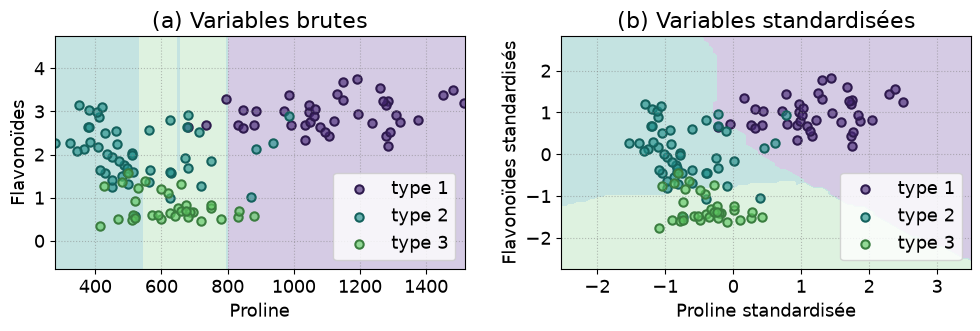

In [9]:
from sklearn.inspection import DecisionBoundaryDisplay
from matplotlib.colors import to_rgba

# Régions de décision avant et après standardisation
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

X_w_tr_std = scaler.transform(X_w_tr)

panneaux = [
    (knn_brut, X_w_tr,
     '(a) Variables brutes',
     'Proline', 'Flavonoïdes'),

    (knn_std, X_w_tr_std,
     '(b) Variables standardisées',
     'Proline standardisée', 'Flavonoïdes standardisés')
]

for ax, (modele, donnees, titre, xlabel, ylabel) in zip(axes, panneaux):
    DecisionBoundaryDisplay.from_estimator(
        modele, donnees, multiclass_colors=[ZONE[VIOLET], ZONE[SARCELLE], ZONE[VERT]],
        response_method='predict', ax=ax)

    for cls, coul in enumerate([VIOLET, SARCELLE, VERT]):
        idx = y_w_tr == cls
        ax.scatter(donnees[idx, 0], donnees[idx, 1],
                   color=to_rgba(coul, 0.65), edgecolors=BORD[coul],
                   linewidths=1.5, label=f'type {cls + 1}')

    ax.set_title(titre)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(True, color='gray', linestyle=':', linewidth=0.8, alpha=0.5)

fig.tight_layout()

# Sauvegarder la figure
save_figure(fig, "Figures/Fig_Chap7_knn_echelles")

plt.show()

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 7.6 : Standardisation et classification au sein d'un pipeline</h3>

In [10]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('normalisation', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=15))
])
pipeline.fit(X_w_tr, y_w_tr)

# Affichage
print('Exactitude (pipeline) :',
      round(pipeline.score(X_w_te, y_w_te), 3))

Exactitude (pipeline) : 0.944


<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 7.7 : Sélection de $k$ et du mode de pondération par validation croisée (<em>Wine</em> complet)</h3>

In [11]:
from sklearn.model_selection import GridSearchCV

X_tr, X_te, y_tr, y_te = train_test_split(
    wine.data, wine.target, test_size=0.3,
    stratify=wine.target, random_state=42)

pipeline = Pipeline([
    ('normalisation', StandardScaler()),
    ('knn', KNeighborsClassifier())
])
grille = {'knn__n_neighbors': np.arange(1, 31),
          'knn__weights': ['uniform', 'distance']}

recherche = GridSearchCV(pipeline, grille, cv=5)
recherche.fit(X_tr, y_tr)
meilleur_score = recherche.best_score_
meilleures = [
    (params['knn__n_neighbors'], params['knn__weights'])
    for params, score in zip(
        recherche.cv_results_['params'],
        recherche.cv_results_['mean_test_score']
    )
    if np.isclose(score, meilleur_score)
]
exactitude_test = recherche.score(X_te, y_te)

# --- Affichage ---
titre = "Recherche sur grille (k-PPV, Wine, cv=5)"
L = max(45, len(titre))

print("=" * L)
print(titre)
print("=" * L)
print("Configurations optimales :")
print(f"{'k':<12}{'Poids'}")
print("-" * L)
for k, poids in meilleures:
    print(f"{k:<12}{poids}")
print("-" * L)
print(f"{'Exactitude (validation croisée)':<34}{meilleur_score:.3f}")
print(f"{'Exactitude (test, modèle retenu)':<34}{exactitude_test:.3f}")
print("=" * L)

Recherche sur grille (k-PPV, Wine, cv=5)
Configurations optimales :
k           Poids
---------------------------------------------
12          uniform
29          distance
30          distance
---------------------------------------------
Exactitude (validation croisée)   0.968
Exactitude (test, modèle retenu)  0.963


<h3><span style="font-size: 30px">&#127924;</span> Figure : Évolution des régions de décision selon $k$ (<em>Iris</em>)</h3>

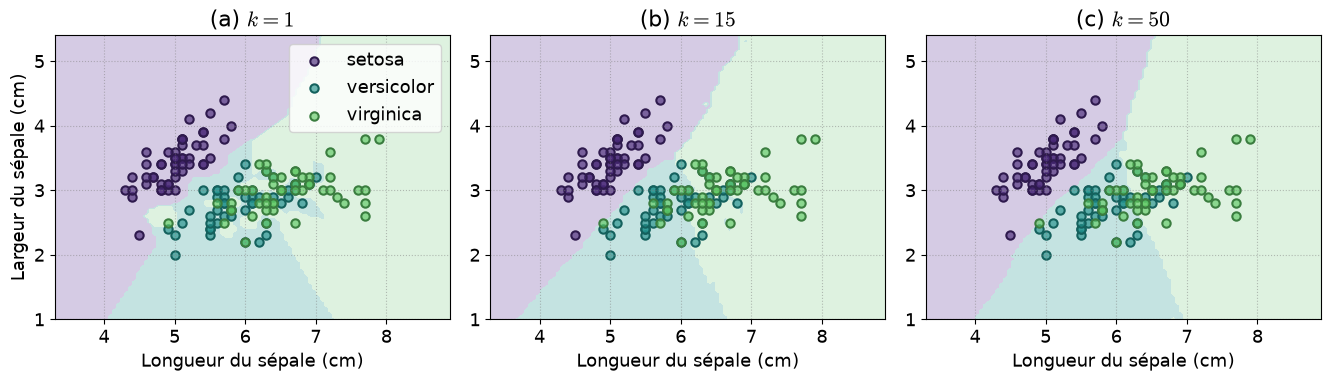

In [12]:
# Régions de décision pour k = 1, 15 et 50 (variables du sépale)
X_s = iris.data[:, :2]
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4))

for ax, k, panneau in zip(axes, [1, 15, 50], ["(a)", "(b)", "(c)"]):
    modele = KNeighborsClassifier(n_neighbors=k).fit(X_s, iris.target)

    DecisionBoundaryDisplay.from_estimator(
        modele,
        X_s,
        multiclass_colors=[ZONE[VIOLET], ZONE[SARCELLE], ZONE[VERT]],
        response_method='predict',
        ax=ax
    )

    for cls, coul in enumerate([VIOLET, SARCELLE, VERT]):
        idx = iris.target == cls
        ax.scatter(X_s[idx, 0], X_s[idx, 1],
                   color=to_rgba(coul, 0.65),
                   edgecolors=BORD[coul],
                   linewidths=1.5,
                   label=iris.target_names[cls])

    ax.set_title(f'{panneau} $k = {k}$')
    ax.set_xlabel('Longueur du sépale (cm)')
    ax.grid(True, color='gray', linestyle=':',
            linewidth=0.8, alpha=0.5)

axes[0].set_ylabel('Largeur du sépale (cm)')
axes[0].legend()

fig.tight_layout()

# Sauvegarder la figure
save_figure(fig, "Figures/Fig_Chap7_knn_choix_k")

plt.show()

<h3><span style="font-size: 30px">&#127924;</span> Figure : Erreurs d'entraînement et de validation croisée en fonction de $k$ (<em>Wine</em> complet standardisé)</h3>

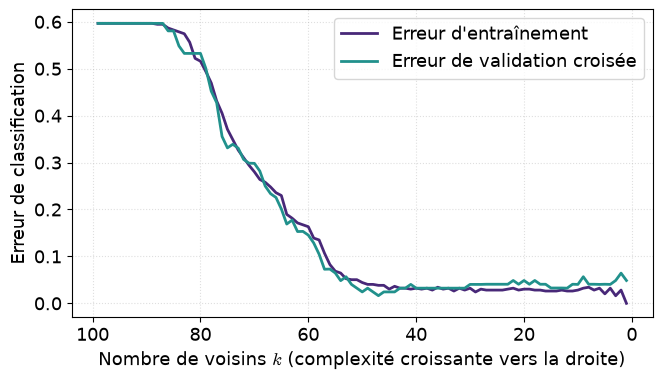

In [13]:
from sklearn.model_selection import cross_validate, StratifiedKFold

# Validation croisée à 5 plis
cv = StratifiedKFold(n_splits=5)

# Valeur maximale de k admissible dans tous les plis d'entraînement
k_max = min(len(ind_tr) for ind_tr, _ in cv.split(X_tr, y_tr))
ks = np.arange(1, k_max + 1)

err_tr, err_cv = [], []

for k in ks:
    mod = Pipeline([
        ('normalisation', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=int(k)))
    ])

    scores = cross_validate(
        mod, X_tr, y_tr,
        cv=cv,
        scoring='accuracy',
        return_train_score=True
    )

    err_tr.append(1 - scores['train_score'].mean())
    err_cv.append(1 - scores['test_score'].mean())

fig, ax = plt.subplots(figsize=(7.5, 4))

ax.plot(ks, err_tr, color=VIOLET, linewidth=2,
        label="Erreur d'entraînement")
ax.plot(ks, err_cv, color=SARCELLE, linewidth=2,
        label='Erreur de validation croisée')

ax.invert_xaxis()
ax.set_xlabel('Nombre de voisins $k$ (complexité croissante vers la droite)')
ax.set_ylabel('Erreur de classification')
ax.legend()
ax.grid(True, linestyle=':', alpha=0.4)

# Sauvegarder la figure
save_figure(fig, "Figures/Fig_Chap7_knn_courbe_k")

plt.show()

<h3><span style="font-size: 30px">&#127924;</span> Figure : Contraste relatif des distances en fonction de la dimension</h3>

Contraste relatif moyen selon la dimension
Dimension     Contraste moyen
---------------------------------------------
2             100.70
5             7.01
10            2.56
20            1.34
50            0.65
100           0.40
200           0.26
500           0.16
1000          0.11


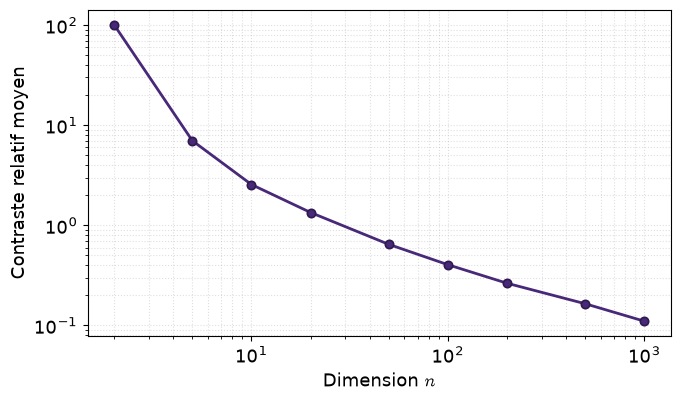

In [14]:
# Contraste (d_max - d_min) / d_min pour m = 500 points uniformes
rng = np.random.RandomState(0)
dimensions = [2, 5, 10, 20, 50, 100, 200, 500, 1000]

contrastes = []
for n_dim in dimensions:
    vals = []
    for _ in range(30):
        pts = rng.uniform(0, 1, size=(500, n_dim))
        requete = rng.uniform(0, 1, size=n_dim)
        d = np.sqrt(((pts - requete) ** 2).sum(axis=1))
        vals.append((d.max() - d.min()) / d.min())
    contrastes.append(np.mean(vals))

# --- Affichage ---
L = 45
print("=" * L)
print("Contraste relatif moyen selon la dimension")
print("=" * L)
print(f"{'Dimension':<14}{'Contraste moyen'}")
print("-" * L)
for n_dim, c in zip(dimensions, contrastes):
    print(f"{n_dim:<14}{c:.2f}")
print("=" * L)

# --- Figure ---
fig, ax = plt.subplots(figsize=(7, 4.2))

ax.plot(dimensions, contrastes, 'o-', color=VIOLET,
        markersize=6, markeredgecolor=BORD[VIOLET], markeredgewidth=1.2,
        linewidth=2)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Dimension $n$')
ax.set_ylabel('Contraste relatif moyen')
ax.tick_params(axis='both')
ax.grid(True, linestyle=':', alpha=0.4, which='both')

plt.tight_layout()

# Sauvegarder la figure
save_figure(fig, "Figures/Fig_Chap7_fleau_dimension")

plt.show()

**Complément** : la variante par rayon fixe (`RadiusNeighborsClassifier`) mentionnée dans le texte, toutes les voisines à distance au plus $r$ votent, leur nombre s'adaptant à la densité locale. Un rayon trop petit laisse des requêtes sans voisine (scikit-learn signale alors une erreur), d'où l'importance de le choisir avec soin.

In [15]:
# Complément : classification par rayon fixe sur Wine standardisé
from sklearn.neighbors import RadiusNeighborsClassifier

rnc = Pipeline([
    ('normalisation', StandardScaler()),
    ('rnc', RadiusNeighborsClassifier(radius=4.0))
])
rnc.fit(X_tr, y_tr)
print('Exactitude (rayon r = 4.0) :',
      round(rnc.score(X_te, y_te), 3))

Exactitude (rayon r = 4.0) : 0.944


<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 7.8 : Régression par $k$ plus proches voisins sur <em>diabetes</em></h3>

In [16]:
from sklearn.datasets import load_diabetes
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler

# Chargement des variables dans leur échelle d'origine,
# sans mise à l'échelle automatique
diab = load_diabetes(scaled=False)
X_d_tr, X_d_te, y_d_tr, y_d_te = train_test_split(
    diab.data, diab.target, test_size=0.3, random_state=42)

# Standardisation à partir de l'ensemble d'entraînement uniquement
scaler = StandardScaler()
X_d_tr = scaler.fit_transform(X_d_tr)
X_d_te = scaler.transform(X_d_te)

# Valeurs fixées à l'avance à des fins illustratives :
# elles ne servent pas à sélectionner k à partir de l'ensemble de test
resultats = []
for k in (1, 10, 50):
    reg = KNeighborsRegressor(n_neighbors=k).fit(X_d_tr, y_d_tr)
    resultats.append((k, reg.score(X_d_te, y_d_te)))

# --- Affichage ---
titre = "k-PPV en régression (Diabetes) : effet de k"
L = max(40, len(titre))

print("=" * L)
print(titre)
print("=" * L)
print(f"{'k':<12}{'R² (test)'}")
print("-" * L)
for k, r2 in resultats:
    print(f"{k:<12}{r2:.3f}")
print("=" * L)

k-PPV en régression (Diabetes) : effet de k
k           R² (test)
-------------------------------------------
1           -0.105
10          0.413
50          0.431


<h3><span style="font-size: 30px">&#127924;</span> Figure : Régression $k$-PPV sur <em>diabetes</em> (variable bmi)</h3>

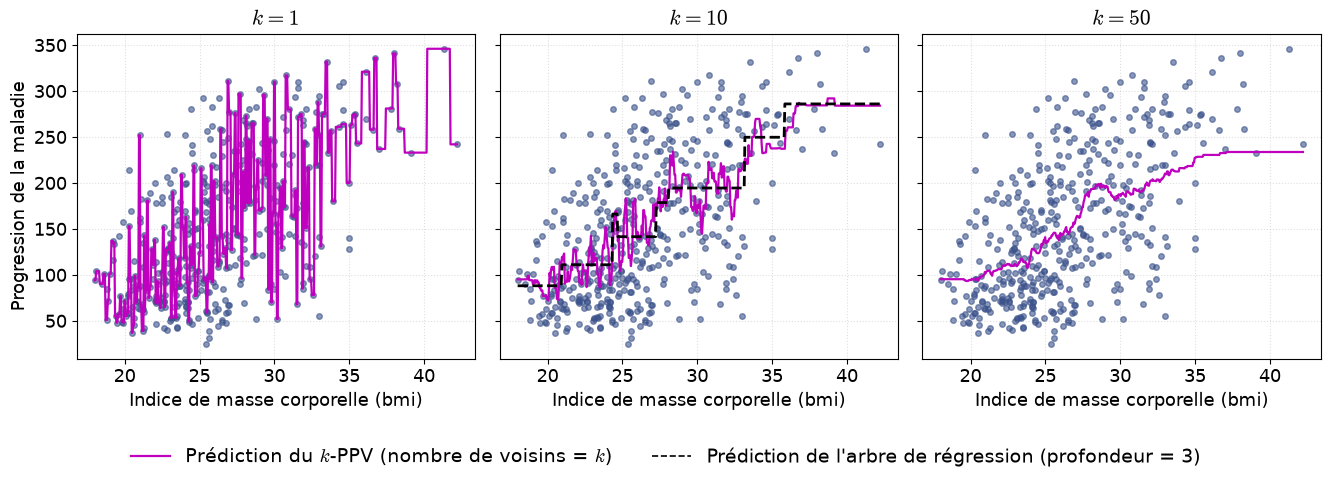

In [17]:
# Visualisation illustrative sur la seule variable bmi
from sklearn.tree import DecisionTreeRegressor
from matplotlib.lines import Line2D

i_bmi = list(diab.feature_names).index('bmi')
x_bmi = diab.data[:, [i_bmi]]
grille_bmi = np.linspace(x_bmi.min(), x_bmi.max(), 500).reshape(-1, 1)

# Arbre de régression utilisé uniquement pour comparaison visuelle
arbre3 = DecisionTreeRegressor(max_depth=3, random_state=42).fit(x_bmi, diab.target)

fig, axes = plt.subplots(1, 3, figsize=(13.5, 5), sharey=True)

for ax, k in zip(axes, [1, 10, 50]):
    # Ajustement sur l'ensemble des observations pour la visualisation
    reg_k = KNeighborsRegressor(n_neighbors=k).fit(x_bmi, diab.target)

    ax.scatter(x_bmi, diab.target, s=16, color='#3b528b', alpha=0.6)
    ax.plot(grille_bmi, reg_k.predict(grille_bmi),
            color='#bf00bf', linewidth=1.6)

    if k == 10:
        ax.plot(grille_bmi, arbre3.predict(grille_bmi),
                'k--', linewidth=2)

    ax.set_title(f'$k = {k}$')
    ax.set_xlabel('Indice de masse corporelle (bmi)')
    ax.grid(True, linestyle=':', alpha=0.4)

axes[0].set_ylabel('Progression de la maladie')

# Légende commune aux trois sous-graphiques
legende = [
    Line2D([0], [0], color='#bf00bf', linewidth=1.6,
           label=r'Prédiction du $k$-PPV (nombre de voisins = $k$)'),
    Line2D([0], [0], color='black', linestyle='--', linewidth=1.2,
           label="Prédiction de l'arbre de régression (profondeur = 3)")
]

fig.legend(handles=legende, loc='lower center', bbox_to_anchor=(0.5, 0.01),
           ncol=2, fontsize=14, frameon=False)

fig.tight_layout(rect=[0, 0.12, 1, 1])

# Sauvegarder avant l'affichage
save_figure(fig, "Figures/Fig_Chap7_knn_regression")
plt.show()

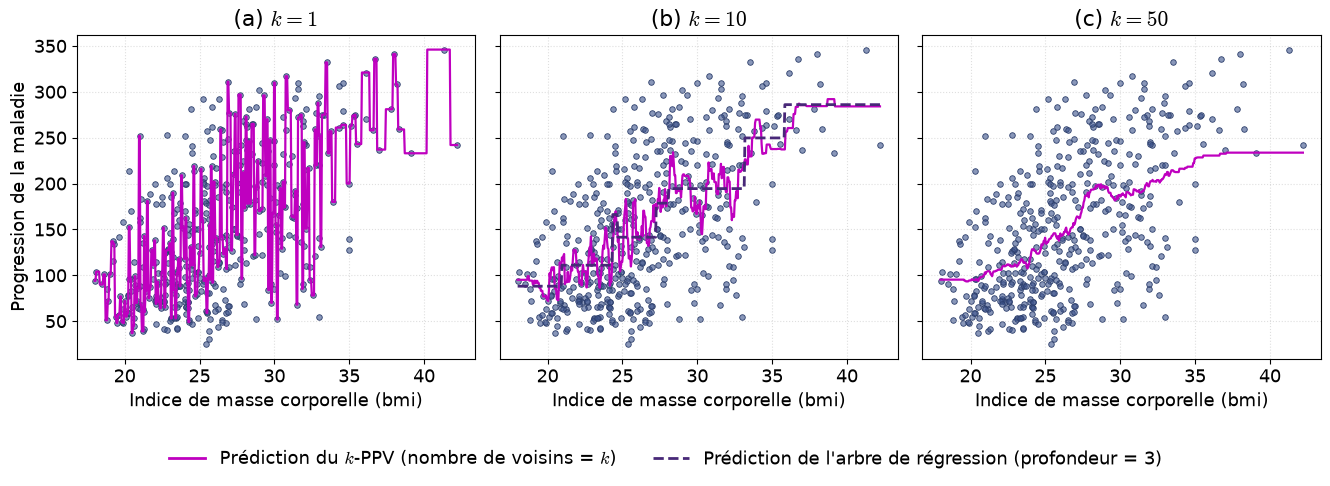

In [18]:
# Visualisation illustrative sur la seule variable bmi
from sklearn.tree import DecisionTreeRegressor
from matplotlib.lines import Line2D
from matplotlib.colors import to_rgba

i_bmi = list(diab.feature_names).index('bmi')
x_bmi = diab.data[:, [i_bmi]]
grille_bmi = np.linspace(x_bmi.min(), x_bmi.max(), 500).reshape(-1, 1)

# Arbre de régression utilisé uniquement pour comparaison visuelle
arbre3 = DecisionTreeRegressor(max_depth=3, random_state=42).fit(x_bmi,
                                                                diab.target)

fig, axes = plt.subplots(1, 3, figsize=(13.5, 5), sharey=True)

for ax, k, panneau in zip(axes, [1, 10, 50], ["(a)", "(b)", "(c)"]):
    # Ajustement sur l'ensemble des observations pour la visualisation
    reg_k = KNeighborsRegressor(n_neighbors=k).fit(x_bmi, diab.target)

    ax.scatter(x_bmi, diab.target, s=16, color=to_rgba(BLEU, 0.6),
               edgecolors=BORD[BLEU], linewidths=0.6)
    ax.plot(grille_bmi, reg_k.predict(grille_bmi),
            color=MAGENTA, linewidth=1.6)

    if k == 10:
        ax.plot(grille_bmi, arbre3.predict(grille_bmi),
                color=VIOLET, linestyle='--', linewidth=2)

    ax.set_title(f'{panneau} $k = {k}$')
    ax.set_xlabel('Indice de masse corporelle (bmi)')
    ax.grid(True, linestyle=':', alpha=0.4)

axes[0].set_ylabel('Progression de la maladie')

# Légende commune aux trois sous-graphiques
legende = [
    Line2D([0], [0], color=MAGENTA, linewidth=2,
           label=r'Prédiction du $k$-PPV (nombre de voisins = $k$)'),
    Line2D([0], [0], color=VIOLET, linestyle='--', linewidth=2,
           label="Prédiction de l'arbre de régression (profondeur = 3)")
]

fig.legend(handles=legende, loc='lower center', bbox_to_anchor=(0.5, 0.01),
           ncol=2, frameon=False)

fig.tight_layout(rect=[0, 0.12, 1, 1])

# Sauvegarder avant l'affichage
save_figure(fig, "Figures/Fig_Chap7_knn_regression")

plt.show()

<hr style='border-top:4px solid #1F77B4;'>